In [11]:
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
data = pd.read_csv("california_housing_pipelines_benchmark.csv")

# Categorize implementations into labels
def get_label(impl):
    if impl == 'baseline':
        return 'baseline'
    elif 'skrub' in impl and 'njobs=1' in impl:
        return 'skrub-single-threaded'
    elif 'skrub' in impl and 'njobs=-1' in impl:
        return 'skrub-multi-threaded'
    elif 'stratum' in impl and 'njobs=1' in impl:
        return 'stratum-single-threaded'
    else:
        return 'other'

data['label'] = data['impl'].apply(get_label)
data['optimized'] = data['impl'].str.contains('optimized', case=False)

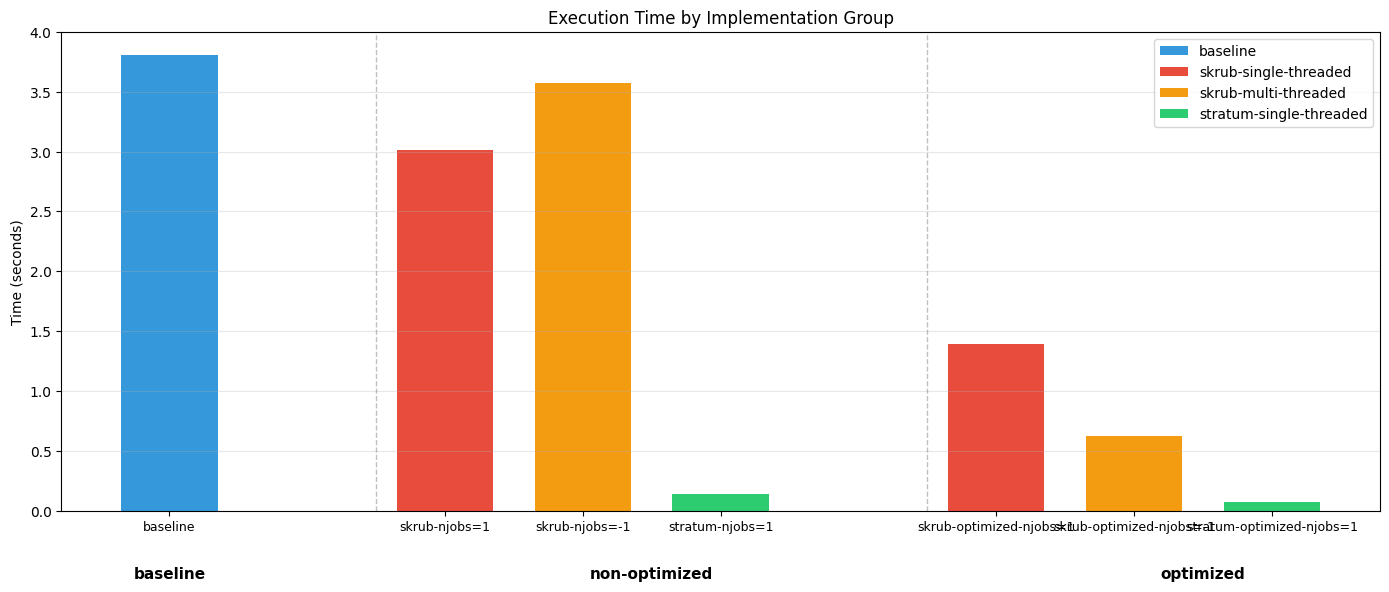

In [17]:
# Single bar chart with 3 groups: baseline, non-optimized, optimized
fig, ax = plt.subplots(figsize=(14, 6))

# Define colors for each label
label_colors = {
    'baseline': '#3498db',
    'skrub-single-threaded': '#e74c3c',
    'skrub-multi-threaded': '#f39c12',
    'stratum-single-threaded': '#2ecc71'
}

# Prepare data: baseline, non-optimized, optimized
label_order = ['skrub-single-threaded', 'skrub-multi-threaded', 'stratum-single-threaded']
plot_data = []

# Baseline
baseline = data[data['label'] == 'baseline']
if len(baseline) > 0:
    plot_data.append({'x': 0, 'time': baseline.iloc[0]['time'], 'label': 'baseline', 'color': label_colors['baseline']})

# Non-optimized
for i, label in enumerate(label_order):
    row = data[(~data['optimized']) & (data['label'] == label)]
    if len(row) > 0:
        plot_data.append({'x': 2 + i, 'time': row.iloc[0]['time'], 'label': row.iloc[0]['impl'], 'color': label_colors[label]})

# Optimized
for i, label in enumerate(label_order):
    row = data[data['optimized'] & (data['label'] == label)]
    if len(row) > 0:
        plot_data.append({'x': 6 + i, 'time': row.iloc[0]['time'], 'label': row.iloc[0]['impl'], 'color': label_colors[label]})

# Create bars
x_pos = [d['x'] for d in plot_data]
heights = [d['time'] for d in plot_data]
colors = [d['color'] for d in plot_data]
labels = [d['label'] for d in plot_data]

ax.bar(x_pos, heights, color=colors, width=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)

# Add group labels
max_height = max(heights)
ax.text(0, -max_height*0.15, 'baseline', ha='center', fontsize=11, fontweight='bold')
ax.text(3.5, -max_height*0.15, 'non-optimized', ha='center', fontsize=11, fontweight='bold')
ax.text(7.5, -max_height*0.15, 'optimized', ha='center', fontsize=11, fontweight='bold')

# Add vertical separators
ax.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time by Implementation Group')
ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=label_colors[k], label=k) for k in label_colors.keys()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()
